In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 


In [14]:
# Import data
df = pd.read_csv('C:/Users/yeiso/OneDrive/Escritorio/Repositorio de git/Proyectos/Page View Time Series Visualizer/fcc-forum-pageviews.csv',
                 index_col='date',
                 parse_dates=True)
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1304 entries, 2016-05-09 to 2019-12-03
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   value   1304 non-null   int64
dtypes: int64(1)
memory usage: 20.4 KB


In [3]:
# Clean Data: Keep only yhe data between 2.5 and 97.5 percentile
df = df[(df['value'] >= df['value'].quantile(0.025)) 
        & (df['value'] <= df['value'].quantile(0.975))]

Text(0, 0.5, 'Page Views')

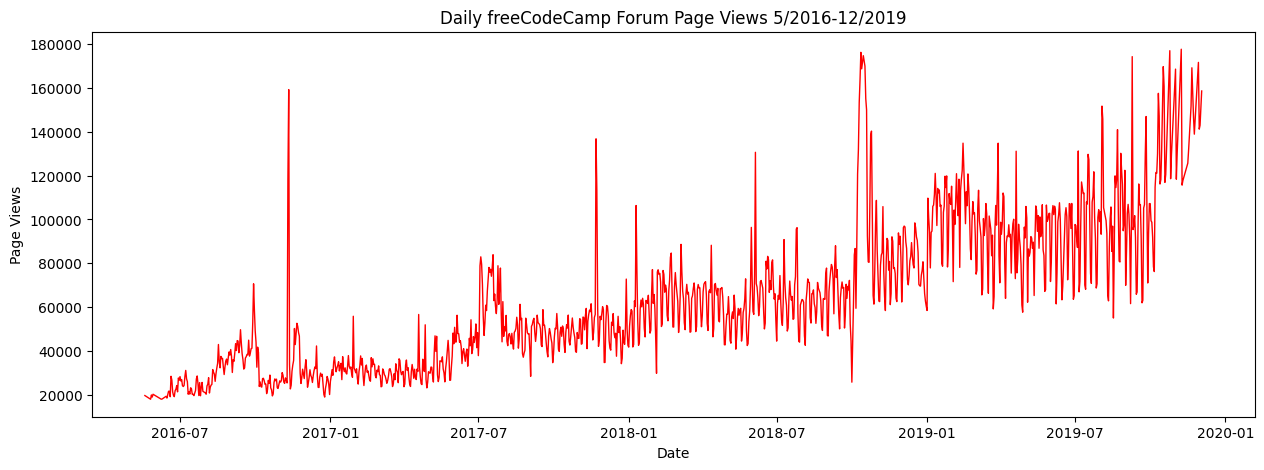

In [4]:
# Draw line plot
fig, ax = plt.subplots(figsize=(15,5))

ax.plot(df.index ,df['value'], color='red', linewidth=1 )

ax.set_title('Daily freeCodeCamp Forum Page Views 5/2016-12/2019')
ax.set_xlabel('Date')
ax.set_ylabel('Page Views')

In [5]:
# draw bar plot
df_bar = df.copy()
df_bar['year'] = df_bar.index.year
df_bar['month'] = df_bar.index.month_name()
df_bar.head()

,value,year,month
date,,,
2016-05-19,19736,2016,May
2016-05-26,18060,2016,May
2016-05-27,19997,2016,May
2016-05-28,19044,2016,May
2016-05-29,20325,2016,May


In [6]:
# Creando una categoría
month_order = ['January', 'February', 'March', 'April',
        'May', 'June', 'July', 'August',
        'September', 'October', 'November', 'December']
    
df_bar['month'] = pd.Categorical(df_bar['month'], categories=month_order, ordered=True)
df_bar.head()

,value,year,month
date,,,
2016-05-19,19736,2016,May
2016-05-26,18060,2016,May
2016-05-27,19997,2016,May
2016-05-28,19044,2016,May
2016-05-29,20325,2016,May


In [7]:
# Group by year
df_bar = df_bar.groupby(['year', 'month'])['value'].mean().unstack()
df_bar.head()

month,January,February,March,April,May,June,July,August,September,October,November,December
year,,,,,,,,,,,,
2016,NaN,NaN,NaN,NaN,19432.400000,21875.105263,24109.678571,31049.193548,41476.866667,27398.322581,40448.633333,27832.419355
2017,32785.161290,31113.071429,29369.096774,30878.733333,34244.290323,43577.500000,65806.838710,47712.451613,47376.800000,47438.709677,57701.566667,48420.580645
2018,58580.096774,65679.000000,62693.774194,62350.833333,56562.870968,70117.000000,63591.064516,62831.612903,65941.733333,111378.142857,78688.333333,80047.483871
2019,102056.516129,105968.357143,91214.483871,89368.433333,91439.903226,90435.642857,97236.566667,102717.310345,97268.833333,122802.272727,143166.428571,150733.500000


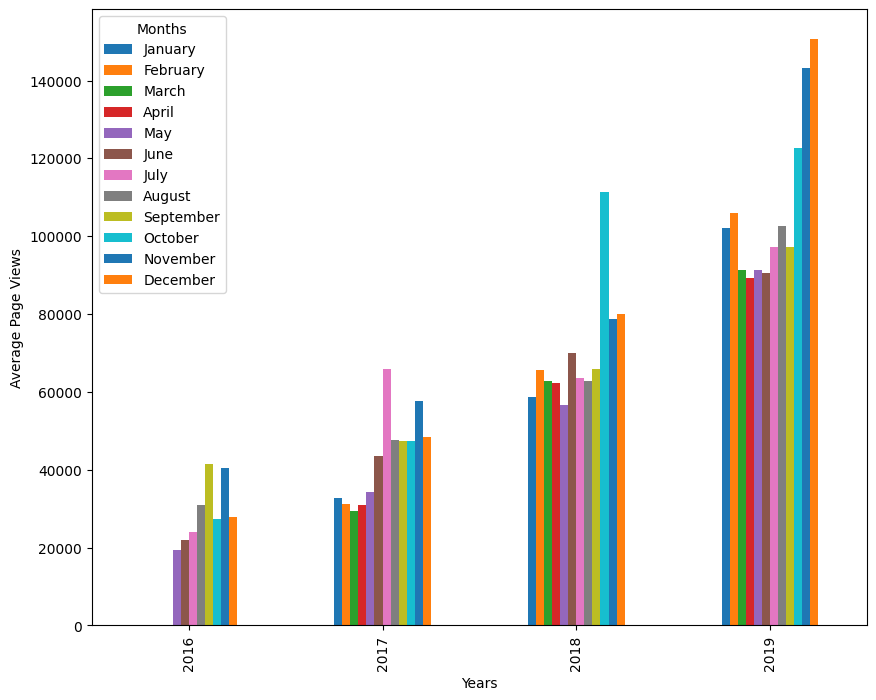

In [8]:
# Draw the bar plot
fig = df_bar.plot(kind='bar', figsize=(10,8)).figure

plt.xlabel('Years')
plt.ylabel('Average Page Views')
plt.legend(title='Months')


In [9]:
#Make a copy of DataFrame
df_box = df.copy()
# Reset the index
df_box.reset_index(inplace=True)

In [10]:
# Make a column year and month
df_box['year'] = df_box['date'].dt.year
df_box['month'] = df_box['date'].dt.strftime('%b')
df_box.head()

,date,value,year,month
0,2016-05-19,19736,2016,May
1,2016-05-26,18060,2016,May
2,2016-05-27,19997,2016,May
3,2016-05-28,19044,2016,May
4,2016-05-29,20325,2016,May


In [11]:
 # Create a categorical column for month
month_order = [
    'Jan', 'Feb', 'Mar', 'Apr',
    'May', 'Jun', 'Jul', 'Aug',
    'Sep', 'Oct', 'Nov', 'Dec'
]
    
df_box['month'] = pd.Categorical(df_box['month'], categories=month_order, ordered=True)
df_box.head()

,date,value,year,month
0,2016-05-19,19736,2016,May
1,2016-05-26,18060,2016,May
2,2016-05-27,19997,2016,May
3,2016-05-28,19044,2016,May
4,2016-05-29,20325,2016,May


Text(0, 0.5, 'Page Views')

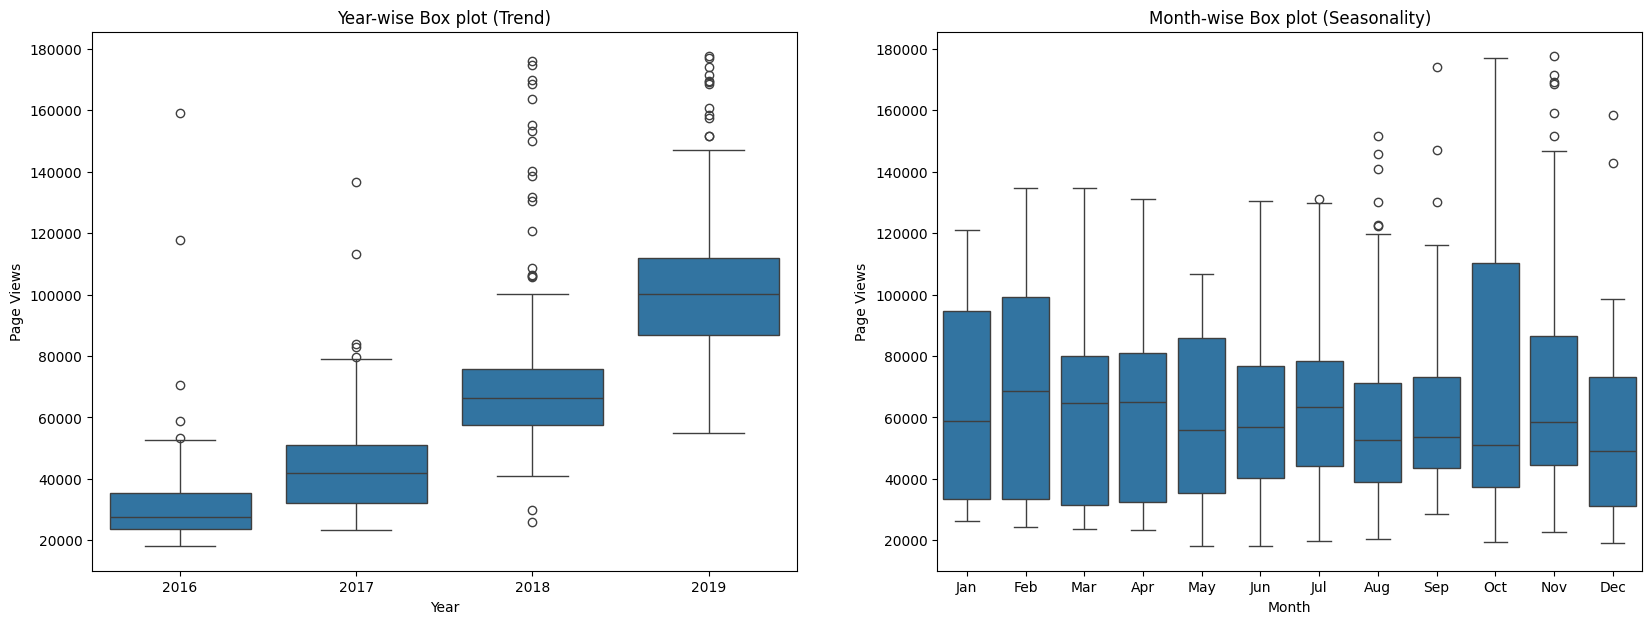

In [12]:
# Draw the box plot
fig, ax = plt.subplots(1,2, figsize=(20,7))

sns.boxplot(x='year', y='value', data = df_box, ax= ax[0])

ax[0].set_title('Year-wise Box plot (Trend)')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Page Views')

sns.boxplot(x='month', y='value', data=df_box, ax=ax[1])

ax[1].set_title('Month-wise Box plot (Seasonality)')
ax[1].set_xlabel('Month')
ax[1].set_ylabel('Page Views')